In [1]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from itertools import combinations

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
chain_dir = "/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_2mio/"
chain_files = sorted(glob.glob(f"{chain_dir}/*.txt"))

n_chains = len(chain_files)
if n_chains == 0:
    raise RuntimeError("No chain files found")

print(f"Found {n_chains} chain files:")

Found 6 chain files:


In [2]:
data_0 = np.loadtxt(chain_files[0])
print(data_0.shape)
print(np.sum(data_0[:,0]))

(698305, 29)
2000000.0


Chain 0: (15000, 14)
Chain 1: (15000, 14)
Chain 2: (15000, 14)
Chain 3: (15000, 14)
Chain 4: (15000, 14)
Chain 5: (15000, 14)


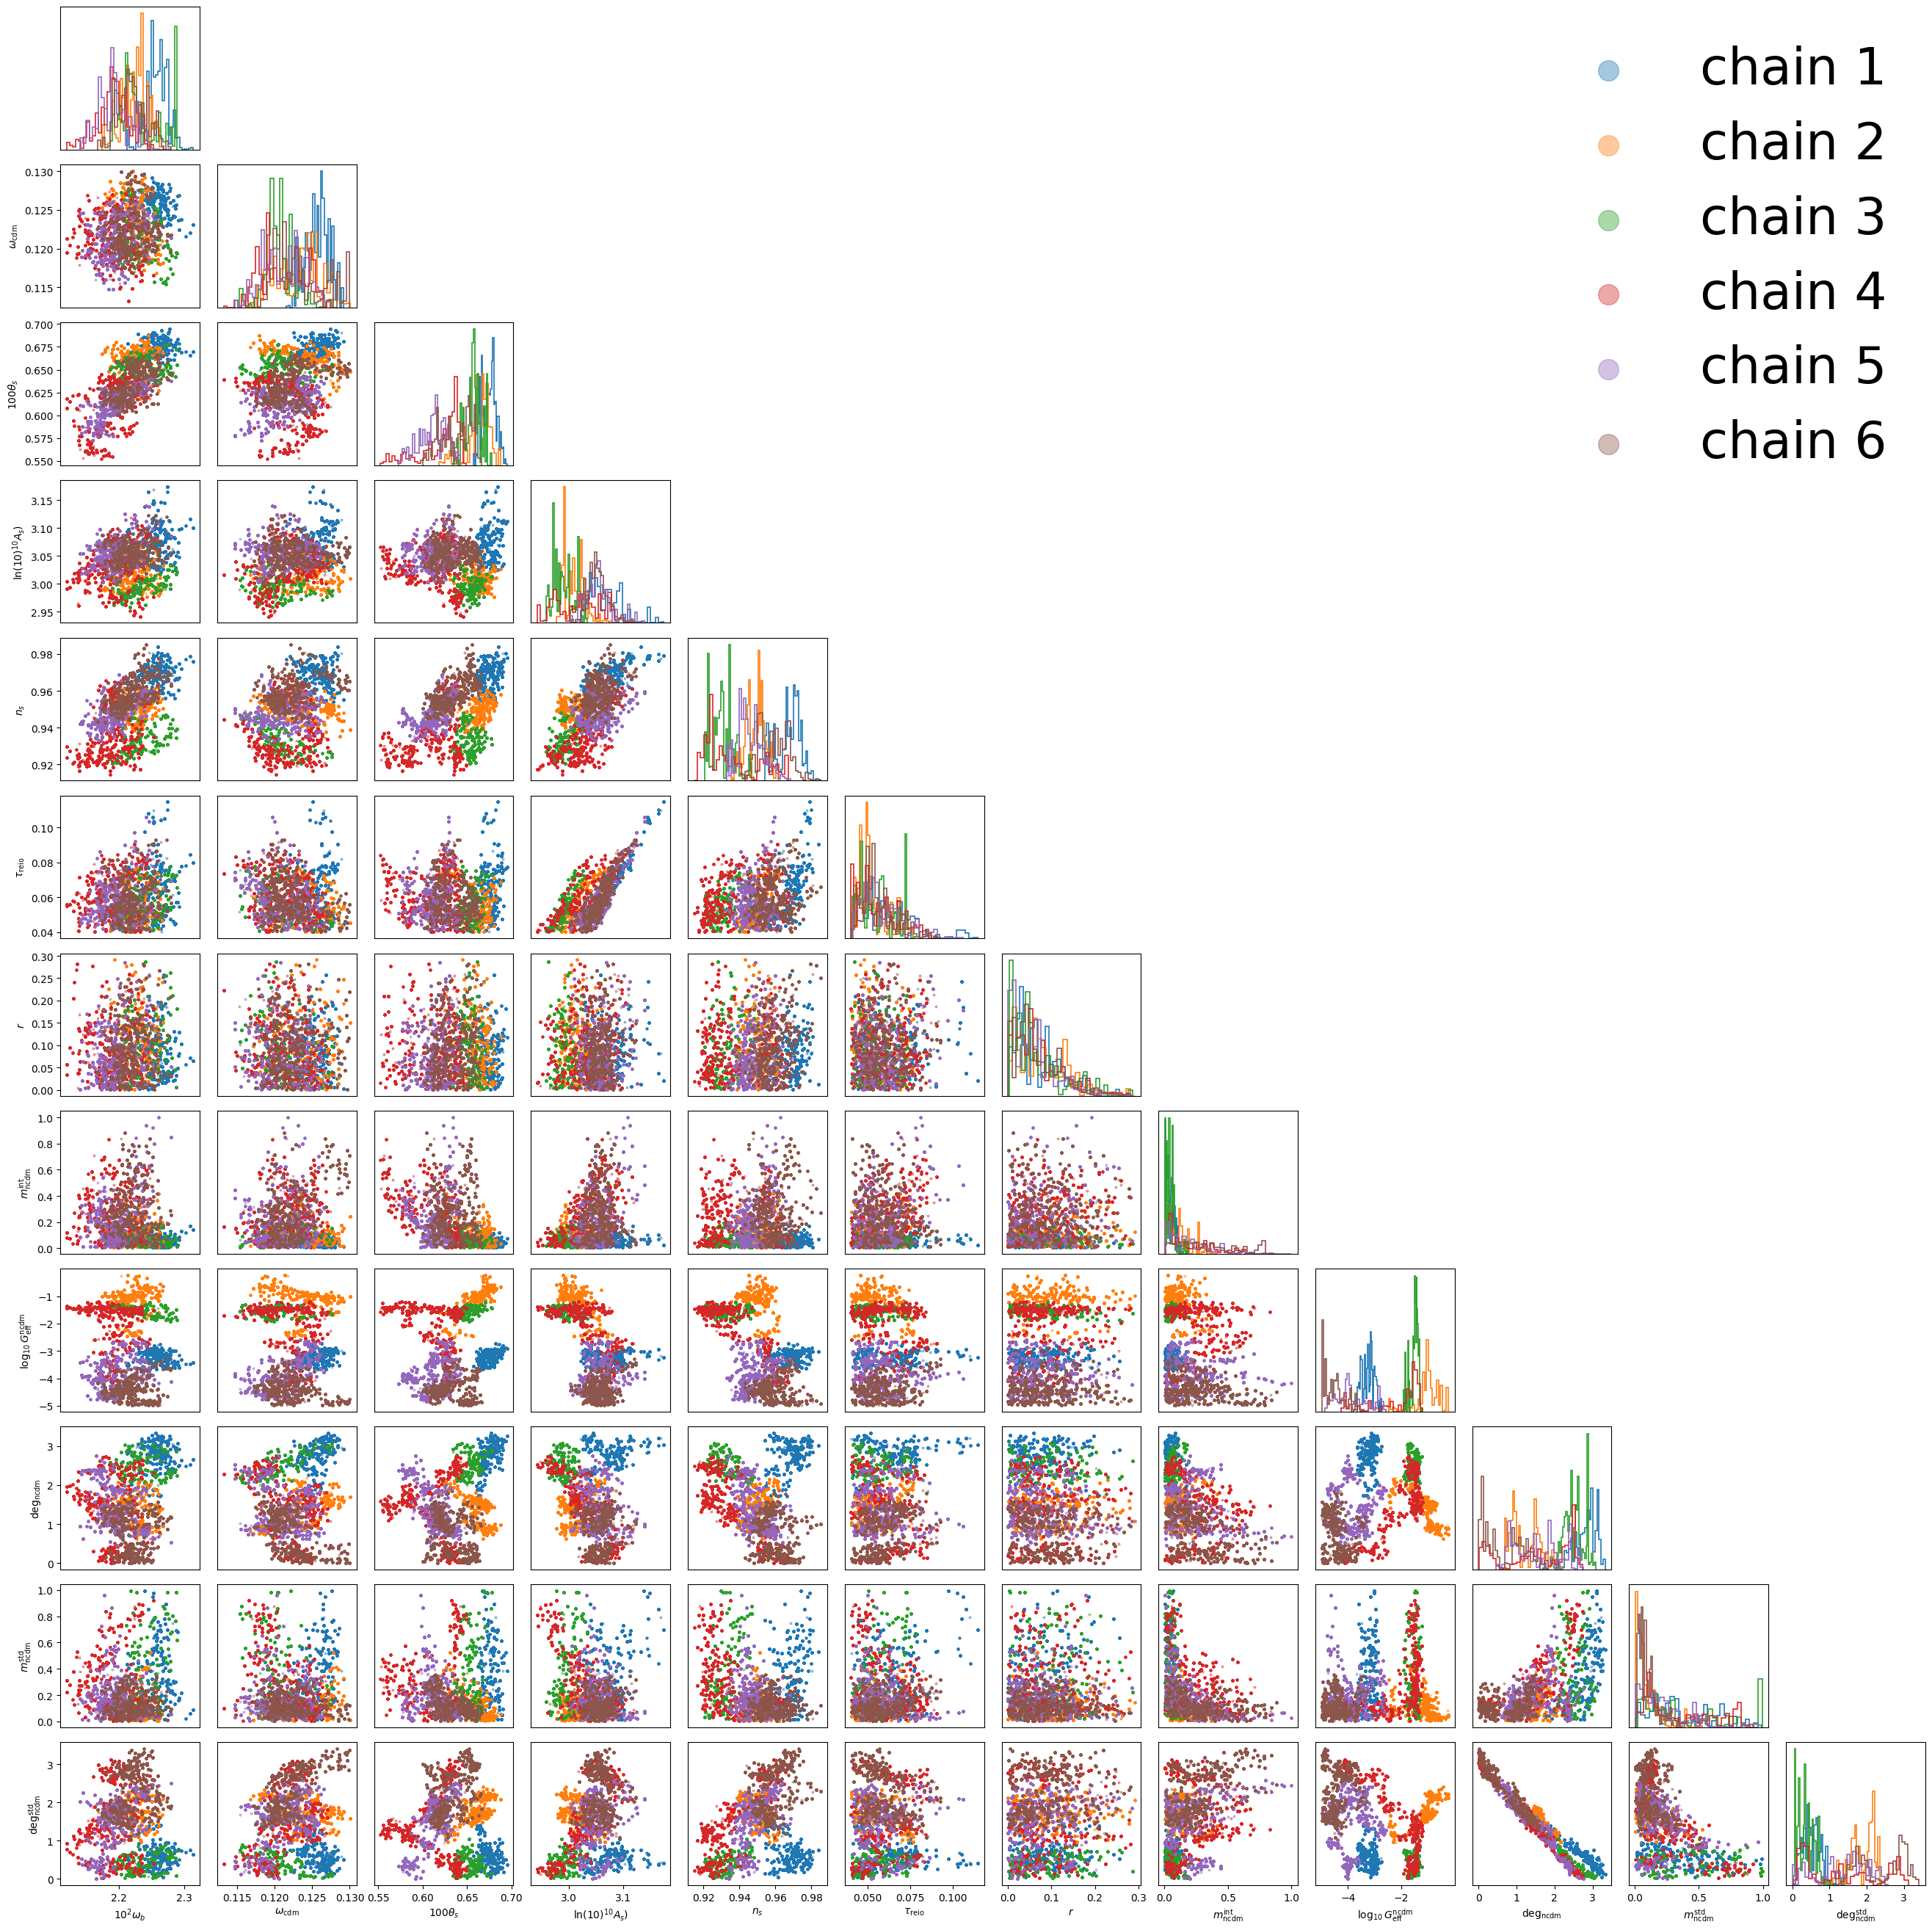

6 chains plotted.


In [10]:
#2 mio chain

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
chain_dir = "/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_2mio/"
chain_files = sorted(glob.glob(f"{chain_dir}/*.txt"))

n_chains = len(chain_files)
if n_chains == 0:
    raise RuntimeError("No chain files found")

# ------------------------------------------------------------------
# Parameters (ORDER MATTERS)
# ------------------------------------------------------------------
param_names = [
    "omega_b",
    "omega_cdm",
    "h",
    "ln10^{10}A_s",
    "n_s",
    "tau_reio",
    "r",
    "m_ncdm_interacting",
    "log10G_eff_ncdm_interacting",
    "deg_ncdm_interacting",
    "m_ncdm_standard",
    'deg_ncdm_standard'
]

param_labels = [
    r"$10^{2}\omega_b$",
    r"$\omega_{\rm cdm}$",
    r"$100\theta_s$",
    r"$\ln(10)^{10}A_s)$",
    r"$n_s$",
    r"$\tau_{\rm reio}$",
    r"$r$",
    r"$m_{\rm ncdm}^{\rm int}$",
    r"$\log_{10} G_{\rm eff}^{\rm ncdm}$",
    r"${\rm deg}_{\rm ncdm}$",
    r"$m_{\rm ncdm}^{\rm std}$",
    r"${\rm deg}_{\rm ncdm}^{\rm std}$"
]

n_params = len(param_names)

# ------------------------------------------------------------------
# Load chains separately
# ------------------------------------------------------------------
chains = []

for f in chain_files:
    data = np.loadtxt(f)
    params = data[-15000:, 2:16]  # drop step + -loglike
    chains.append(params)

for i, chain in enumerate(chains):
    print(f"Chain {i}: {chain.shape}")
# ------------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------------
colors = plt.cm.tab10.colors  # distinct chain colors
alpha = 0.4
s = 4  # marker size

fig, axes = plt.subplots(
    n_params, n_params,
    figsize=(2.2 * n_params, 2.2 * n_params),
    squeeze=False
)

# ------------------------------------------------------------------
# Triangle plotting
# ------------------------------------------------------------------
for i in range(n_params):
    for j in range(n_params):

        ax = axes[i, j]

        # Upper triangle: empty
        if j > i:
            ax.axis("off")
            continue

        # Diagonal: 1D histograms
        if i == j:
            for c, chain in enumerate(chains):
                ax.hist(
                    chain[:, i],
                    bins=30,
                    histtype="step",
                    color=colors[c % len(colors)],
                    linewidth=1.2,
                    density=True,
                )
        # Lower triangle: 2D scatter
        else:
            for c, chain in enumerate(chains):
                ax.scatter(
                    chain[:, j],
                    chain[:, i],
                    s=s,
                    alpha=alpha,
                    color=colors[c % len(colors)],
                    label=f"chain {c+1}" if (i == n_params - 1 and j == 0) else None,
                )

        # Labels
        if i == n_params - 1:
            ax.set_xlabel(param_labels[j], fontsize=10)
        else:
            ax.set_xticks([])

        if j == 0 and i != 0:
            ax.set_ylabel(param_labels[i], fontsize=10)
        else:
            ax.set_yticks([])

# ------------------------------------------------------------------
# Legend (only once)
# ------------------------------------------------------------------
handles, labels = axes[-1, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    fontsize=50,
    frameon=False,
    markerscale=10
)

plt.tight_layout()
plt.show()

print(len(chain_files), "chains plotted.")


Chain 0: (15000, 14)
Chain 1: (15000, 14)
Chain 2: (15000, 14)
Chain 3: (15000, 14)
Chain 4: (15000, 14)
Chain 5: (15000, 14)


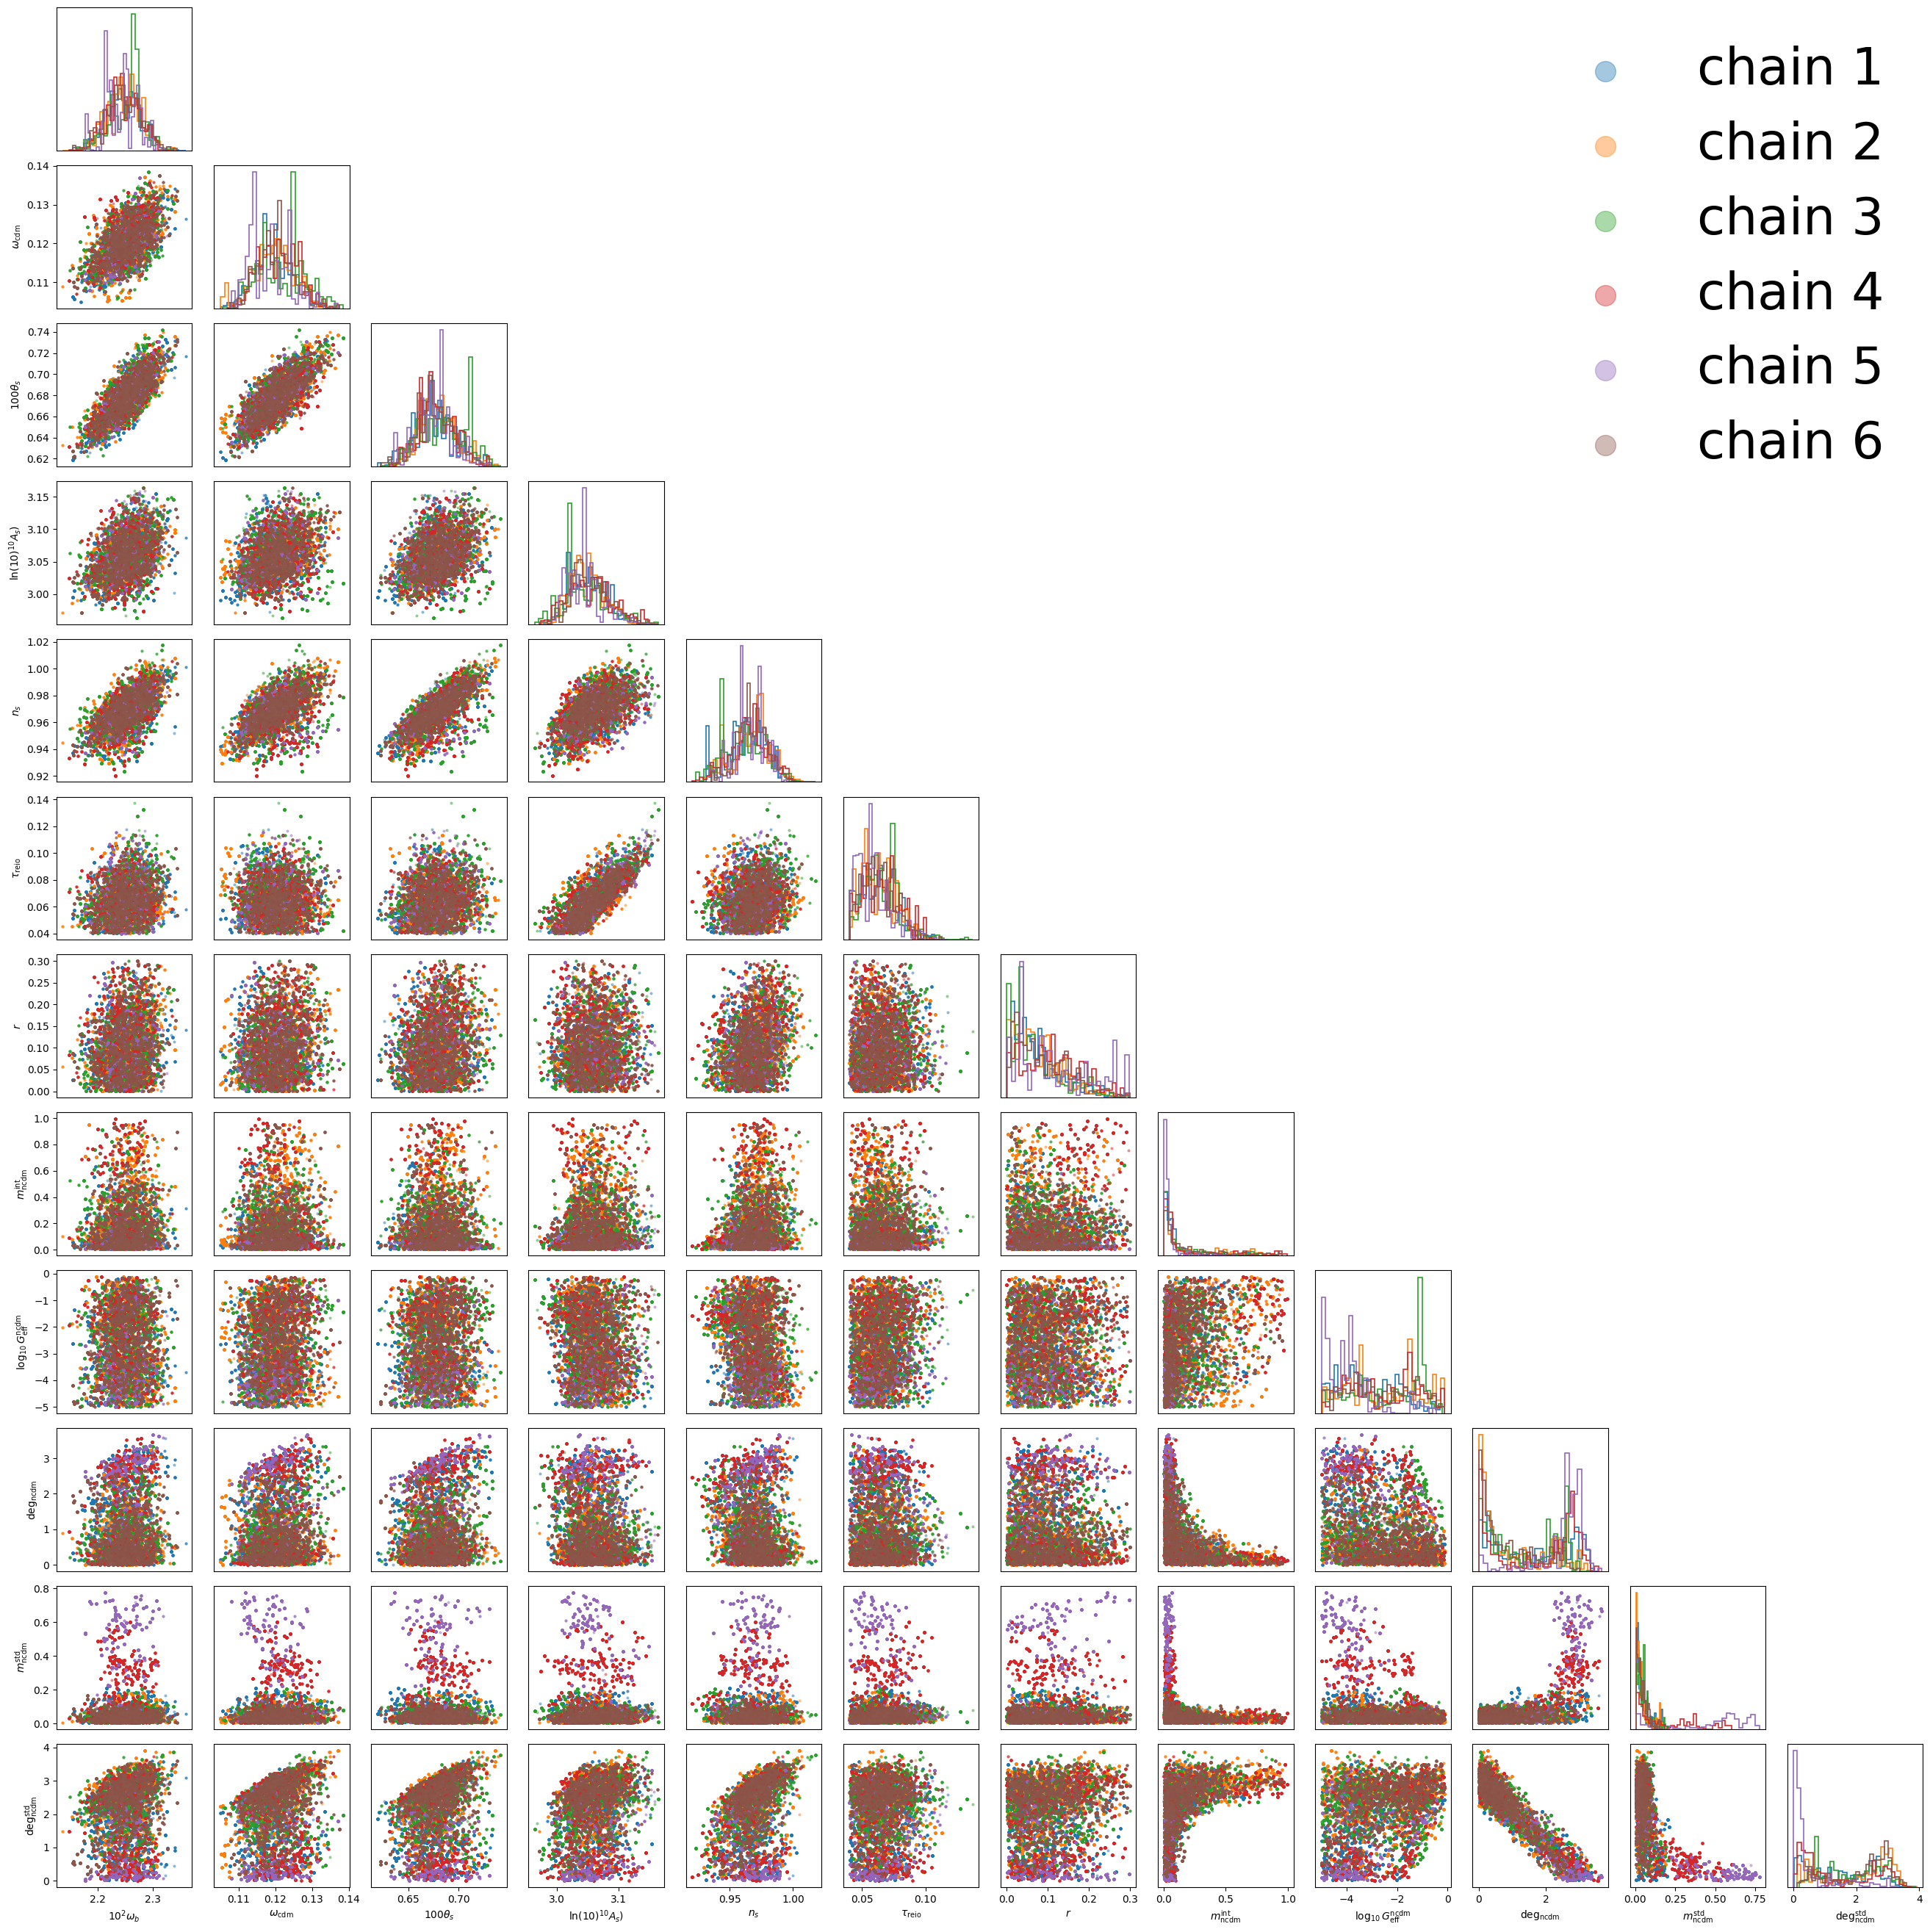

6 chains plotted.


In [11]:
#Checking the 1mio chain run for comparison with the 2mio chain.



# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
chain_dir = "/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_1mio/"
chain_files = sorted(glob.glob(f"{chain_dir}/*.txt"))

n_chains = len(chain_files)
if n_chains == 0:
    raise RuntimeError("No chain files found")

# ------------------------------------------------------------------
# Parameters (ORDER MATTERS)
# ------------------------------------------------------------------
param_names = [
    "omega_b",
    "omega_cdm",
    "h",
    "ln10^{10}A_s",
    "n_s",
    "tau_reio",
    "r",
    "m_ncdm_interacting",
    "log10G_eff_ncdm_interacting",
    "deg_ncdm_interacting",
    "m_ncdm_standard",
    'deg_ncdm_standard'
]

param_labels = [
    r"$10^{2}\omega_b$",
    r"$\omega_{\rm cdm}$",
    r"$100\theta_s$",
    r"$\ln(10)^{10}A_s)$",
    r"$n_s$",
    r"$\tau_{\rm reio}$",
    r"$r$",
    r"$m_{\rm ncdm}^{\rm int}$",
    r"$\log_{10} G_{\rm eff}^{\rm ncdm}$",
    r"${\rm deg}_{\rm ncdm}$",
    r"$m_{\rm ncdm}^{\rm std}$",
    r"${\rm deg}_{\rm ncdm}^{\rm std}$"
]

n_params = len(param_names)

# ------------------------------------------------------------------
# Load chains separately
# ------------------------------------------------------------------
chains = []

for f in chain_files:
    data = np.loadtxt(f)
    params = data[-15000:, 2:16]  # drop step + -loglike
    chains.append(params)

for i, chain in enumerate(chains):
    print(f"Chain {i}: {chain.shape}")
# ------------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------------
colors = plt.cm.tab10.colors  # distinct chain colors
alpha = 0.4
s = 4  # marker size

fig, axes = plt.subplots(
    n_params, n_params,
    figsize=(2.2 * n_params, 2.2 * n_params),
    squeeze=False
)

# ------------------------------------------------------------------
# Triangle plotting
# ------------------------------------------------------------------
for i in range(n_params):
    for j in range(n_params):

        ax = axes[i, j]

        # Upper triangle: empty
        if j > i:
            ax.axis("off")
            continue

        # Diagonal: 1D histograms
        if i == j:
            for c, chain in enumerate(chains):
                ax.hist(
                    chain[:, i],
                    bins=30,
                    histtype="step",
                    color=colors[c % len(colors)],
                    linewidth=1.2,
                    density=True,
                )
        # Lower triangle: 2D scatter
        else:
            for c, chain in enumerate(chains):
                ax.scatter(
                    chain[:, j],
                    chain[:, i],
                    s=s,
                    alpha=alpha,
                    color=colors[c % len(colors)],
                    label=f"chain {c+1}" if (i == n_params - 1 and j == 0) else None,
                )

        # Labels
        if i == n_params - 1:
            ax.set_xlabel(param_labels[j], fontsize=10)
        else:
            ax.set_xticks([])

        if j == 0 and i != 0:
            ax.set_ylabel(param_labels[i], fontsize=10)
        else:
            ax.set_yticks([])

# ------------------------------------------------------------------
# Legend (only once)
# ------------------------------------------------------------------
handles, labels = axes[-1, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    fontsize=50,
    frameon=False,
    markerscale=10
)

plt.tight_layout()
plt.show()

print(len(chain_files), "chains plotted.")


Chain 0: (15000, 14)
Chain 1: (15000, 14)
Chain 2: (15000, 14)
Chain 3: (15000, 14)
Chain 4: (15000, 14)
Chain 5: (15000, 14)


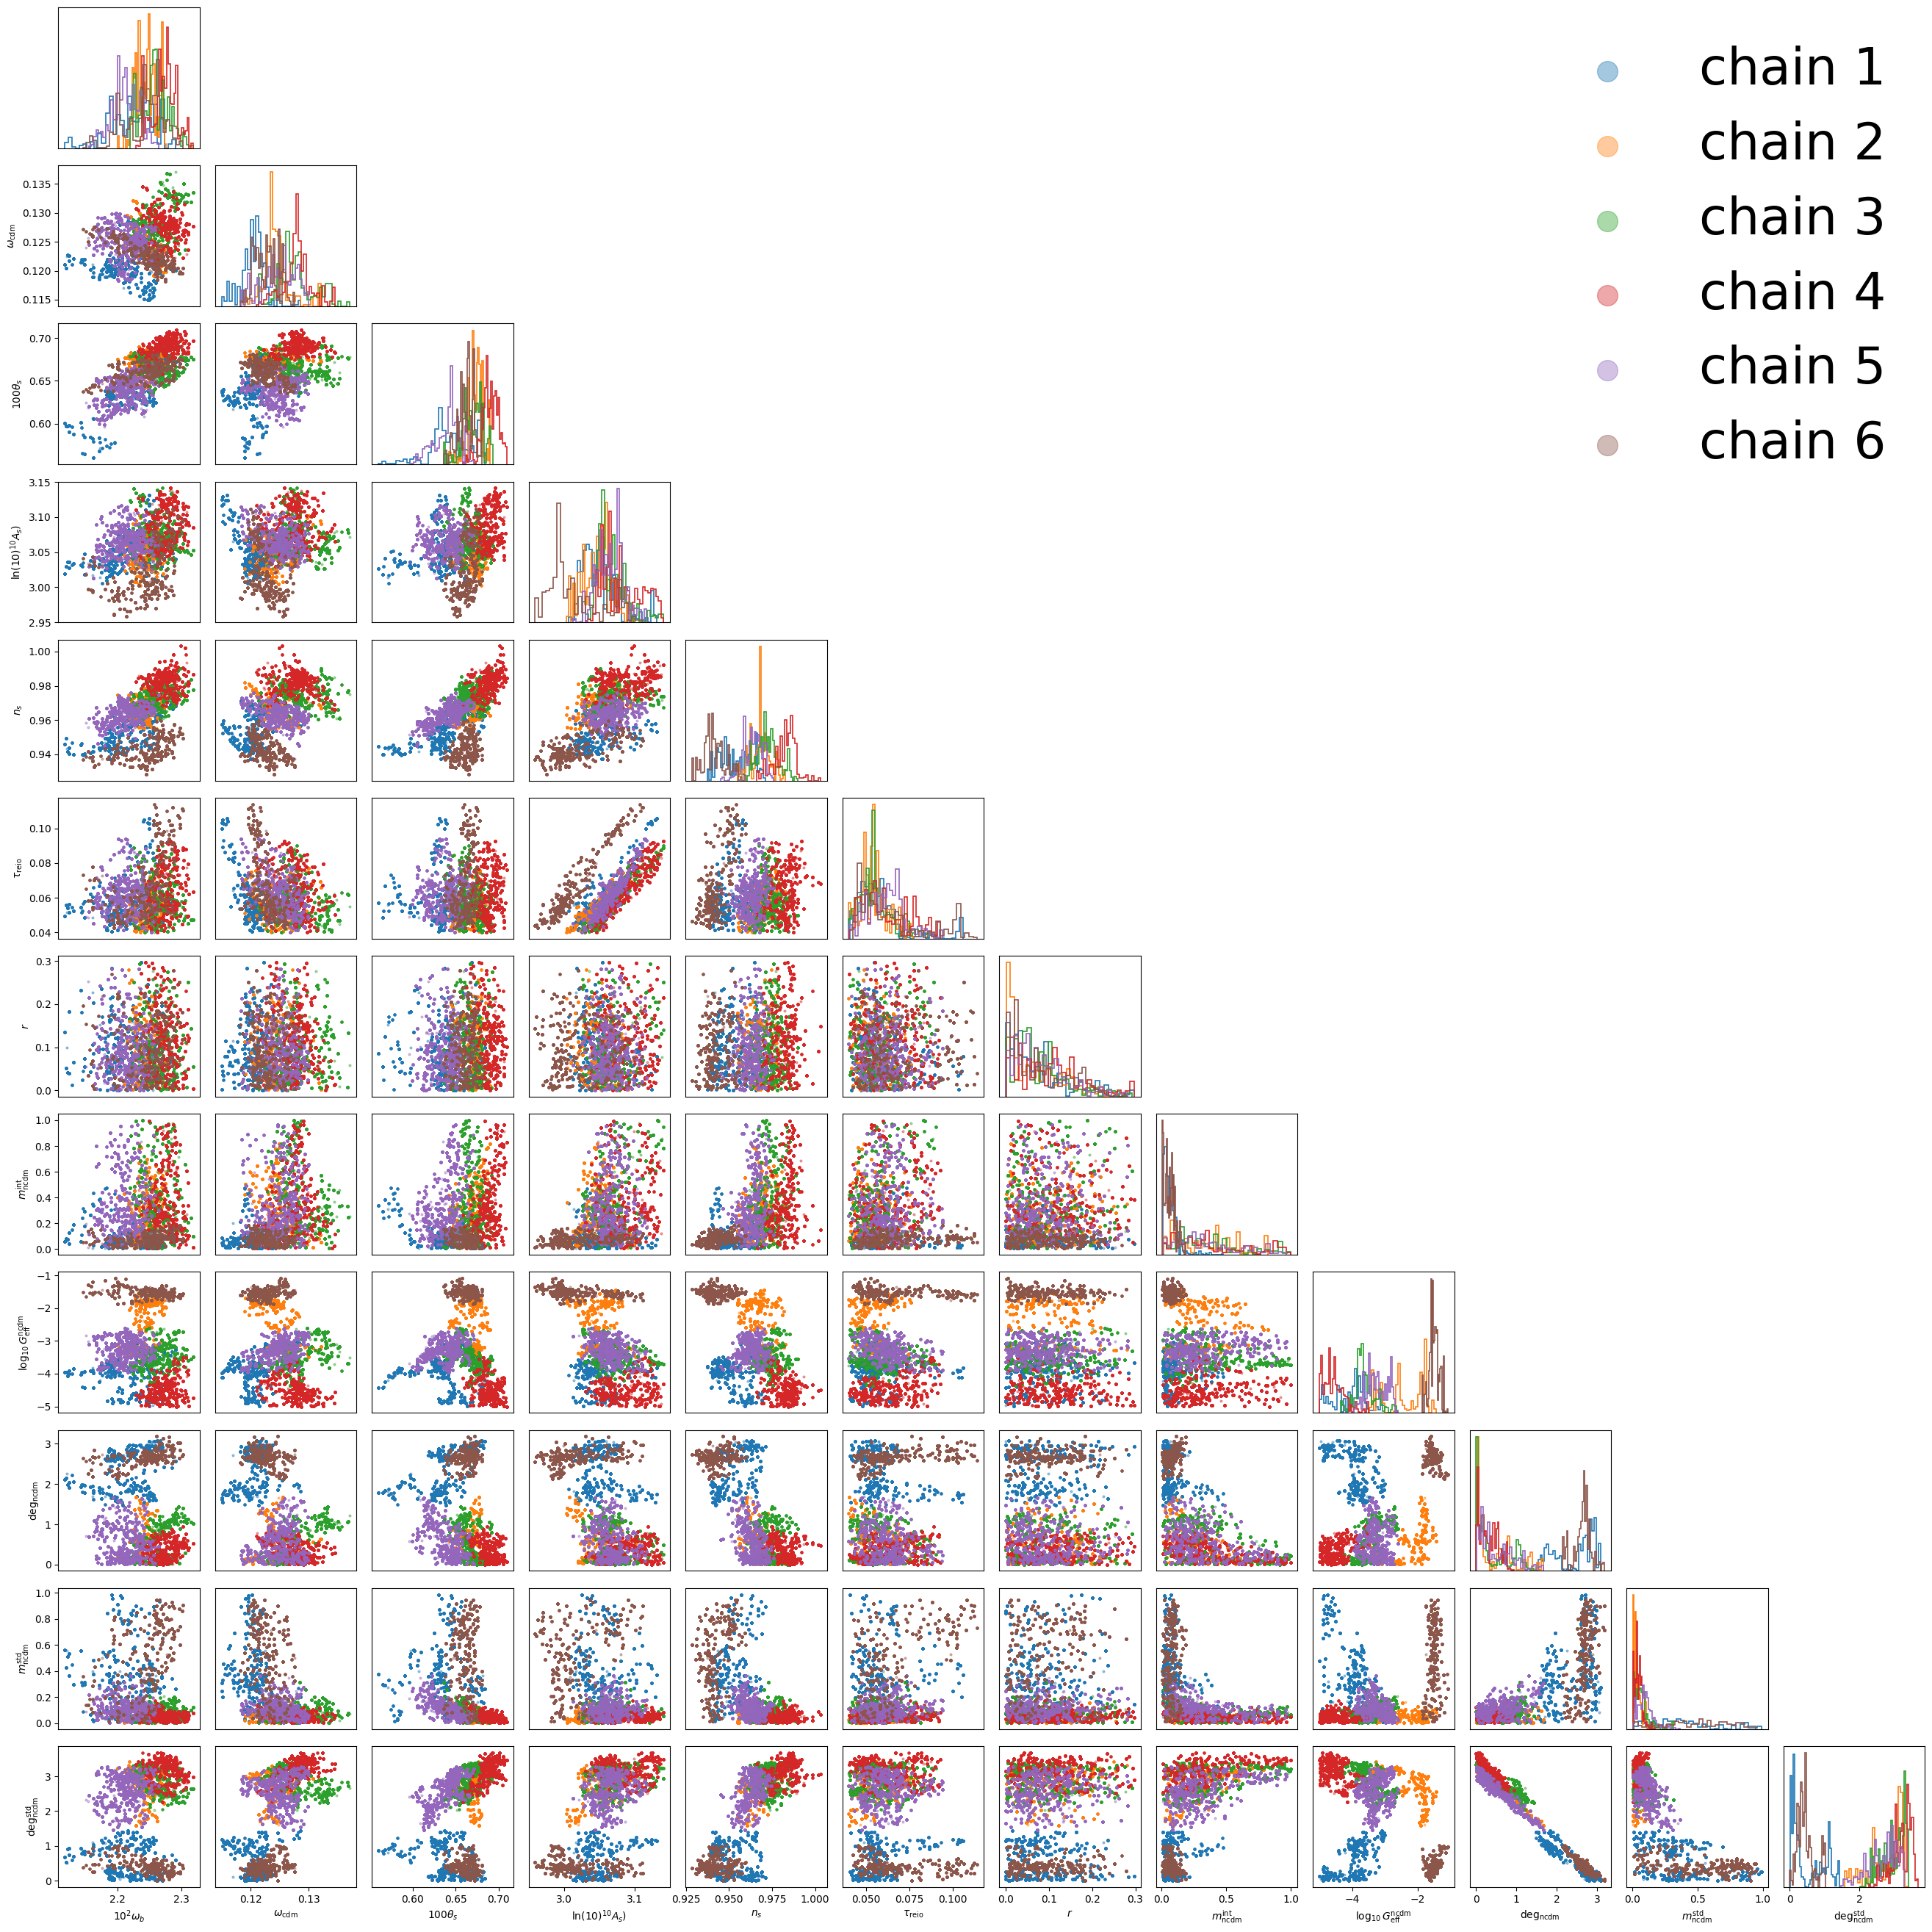

6 chains plotted.


In [12]:
#q64 test run 200k steps



# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
chain_dir = "/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_q64_200k_test/"
chain_files = sorted(glob.glob(f"{chain_dir}/*.txt"))

n_chains = len(chain_files)
if n_chains == 0:
    raise RuntimeError("No chain files found")

# ------------------------------------------------------------------
# Parameters (ORDER MATTERS)
# ------------------------------------------------------------------
param_names = [
    "omega_b",
    "omega_cdm",
    "h",
    "ln10^{10}A_s",
    "n_s",
    "tau_reio",
    "r",
    "m_ncdm_interacting",
    "log10G_eff_ncdm_interacting",
    "deg_ncdm_interacting",
    "m_ncdm_standard",
    'deg_ncdm_standard'
]

param_labels = [
    r"$10^{2}\omega_b$",
    r"$\omega_{\rm cdm}$",
    r"$100\theta_s$",
    r"$\ln(10)^{10}A_s)$",
    r"$n_s$",
    r"$\tau_{\rm reio}$",
    r"$r$",
    r"$m_{\rm ncdm}^{\rm int}$",
    r"$\log_{10} G_{\rm eff}^{\rm ncdm}$",
    r"${\rm deg}_{\rm ncdm}$",
    r"$m_{\rm ncdm}^{\rm std}$",
    r"${\rm deg}_{\rm ncdm}^{\rm std}$"
]

n_params = len(param_names)

# ------------------------------------------------------------------
# Load chains separately
# ------------------------------------------------------------------
chains = []

for f in chain_files:
    data = np.loadtxt(f)
    params = data[-15000:, 2:16]  # drop step + -loglike
    chains.append(params)

for i, chain in enumerate(chains):
    print(f"Chain {i}: {chain.shape}")
# ------------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------------
colors = plt.cm.tab10.colors  # distinct chain colors
alpha = 0.4
s = 4  # marker size

fig, axes = plt.subplots(
    n_params, n_params,
    figsize=(2.2 * n_params, 2.2 * n_params),
    squeeze=False
)

# ------------------------------------------------------------------
# Triangle plotting
# ------------------------------------------------------------------
for i in range(n_params):
    for j in range(n_params):

        ax = axes[i, j]

        # Upper triangle: empty
        if j > i:
            ax.axis("off")
            continue

        # Diagonal: 1D histograms
        if i == j:
            for c, chain in enumerate(chains):
                ax.hist(
                    chain[:, i],
                    bins=30,
                    histtype="step",
                    color=colors[c % len(colors)],
                    linewidth=1.2,
                    density=True,
                )
        # Lower triangle: 2D scatter
        else:
            for c, chain in enumerate(chains):
                ax.scatter(
                    chain[:, j],
                    chain[:, i],
                    s=s,
                    alpha=alpha,
                    color=colors[c % len(colors)],
                    label=f"chain {c+1}" if (i == n_params - 1 and j == 0) else None,
                )

        # Labels
        if i == n_params - 1:
            ax.set_xlabel(param_labels[j], fontsize=10)
        else:
            ax.set_xticks([])

        if j == 0 and i != 0:
            ax.set_ylabel(param_labels[i], fontsize=10)
        else:
            ax.set_yticks([])

# ------------------------------------------------------------------
# Legend (only once)
# ------------------------------------------------------------------
handles, labels = axes[-1, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    fontsize=50,
    frameon=False,
    markerscale=10
)

plt.tight_layout()
plt.show()

print(len(chain_files), "chains plotted.")


Chain 0: (15000, 14)
Chain 1: (15000, 14)
Chain 2: (15000, 14)
Chain 3: (15000, 14)
Chain 4: (15000, 14)
Chain 5: (15000, 14)


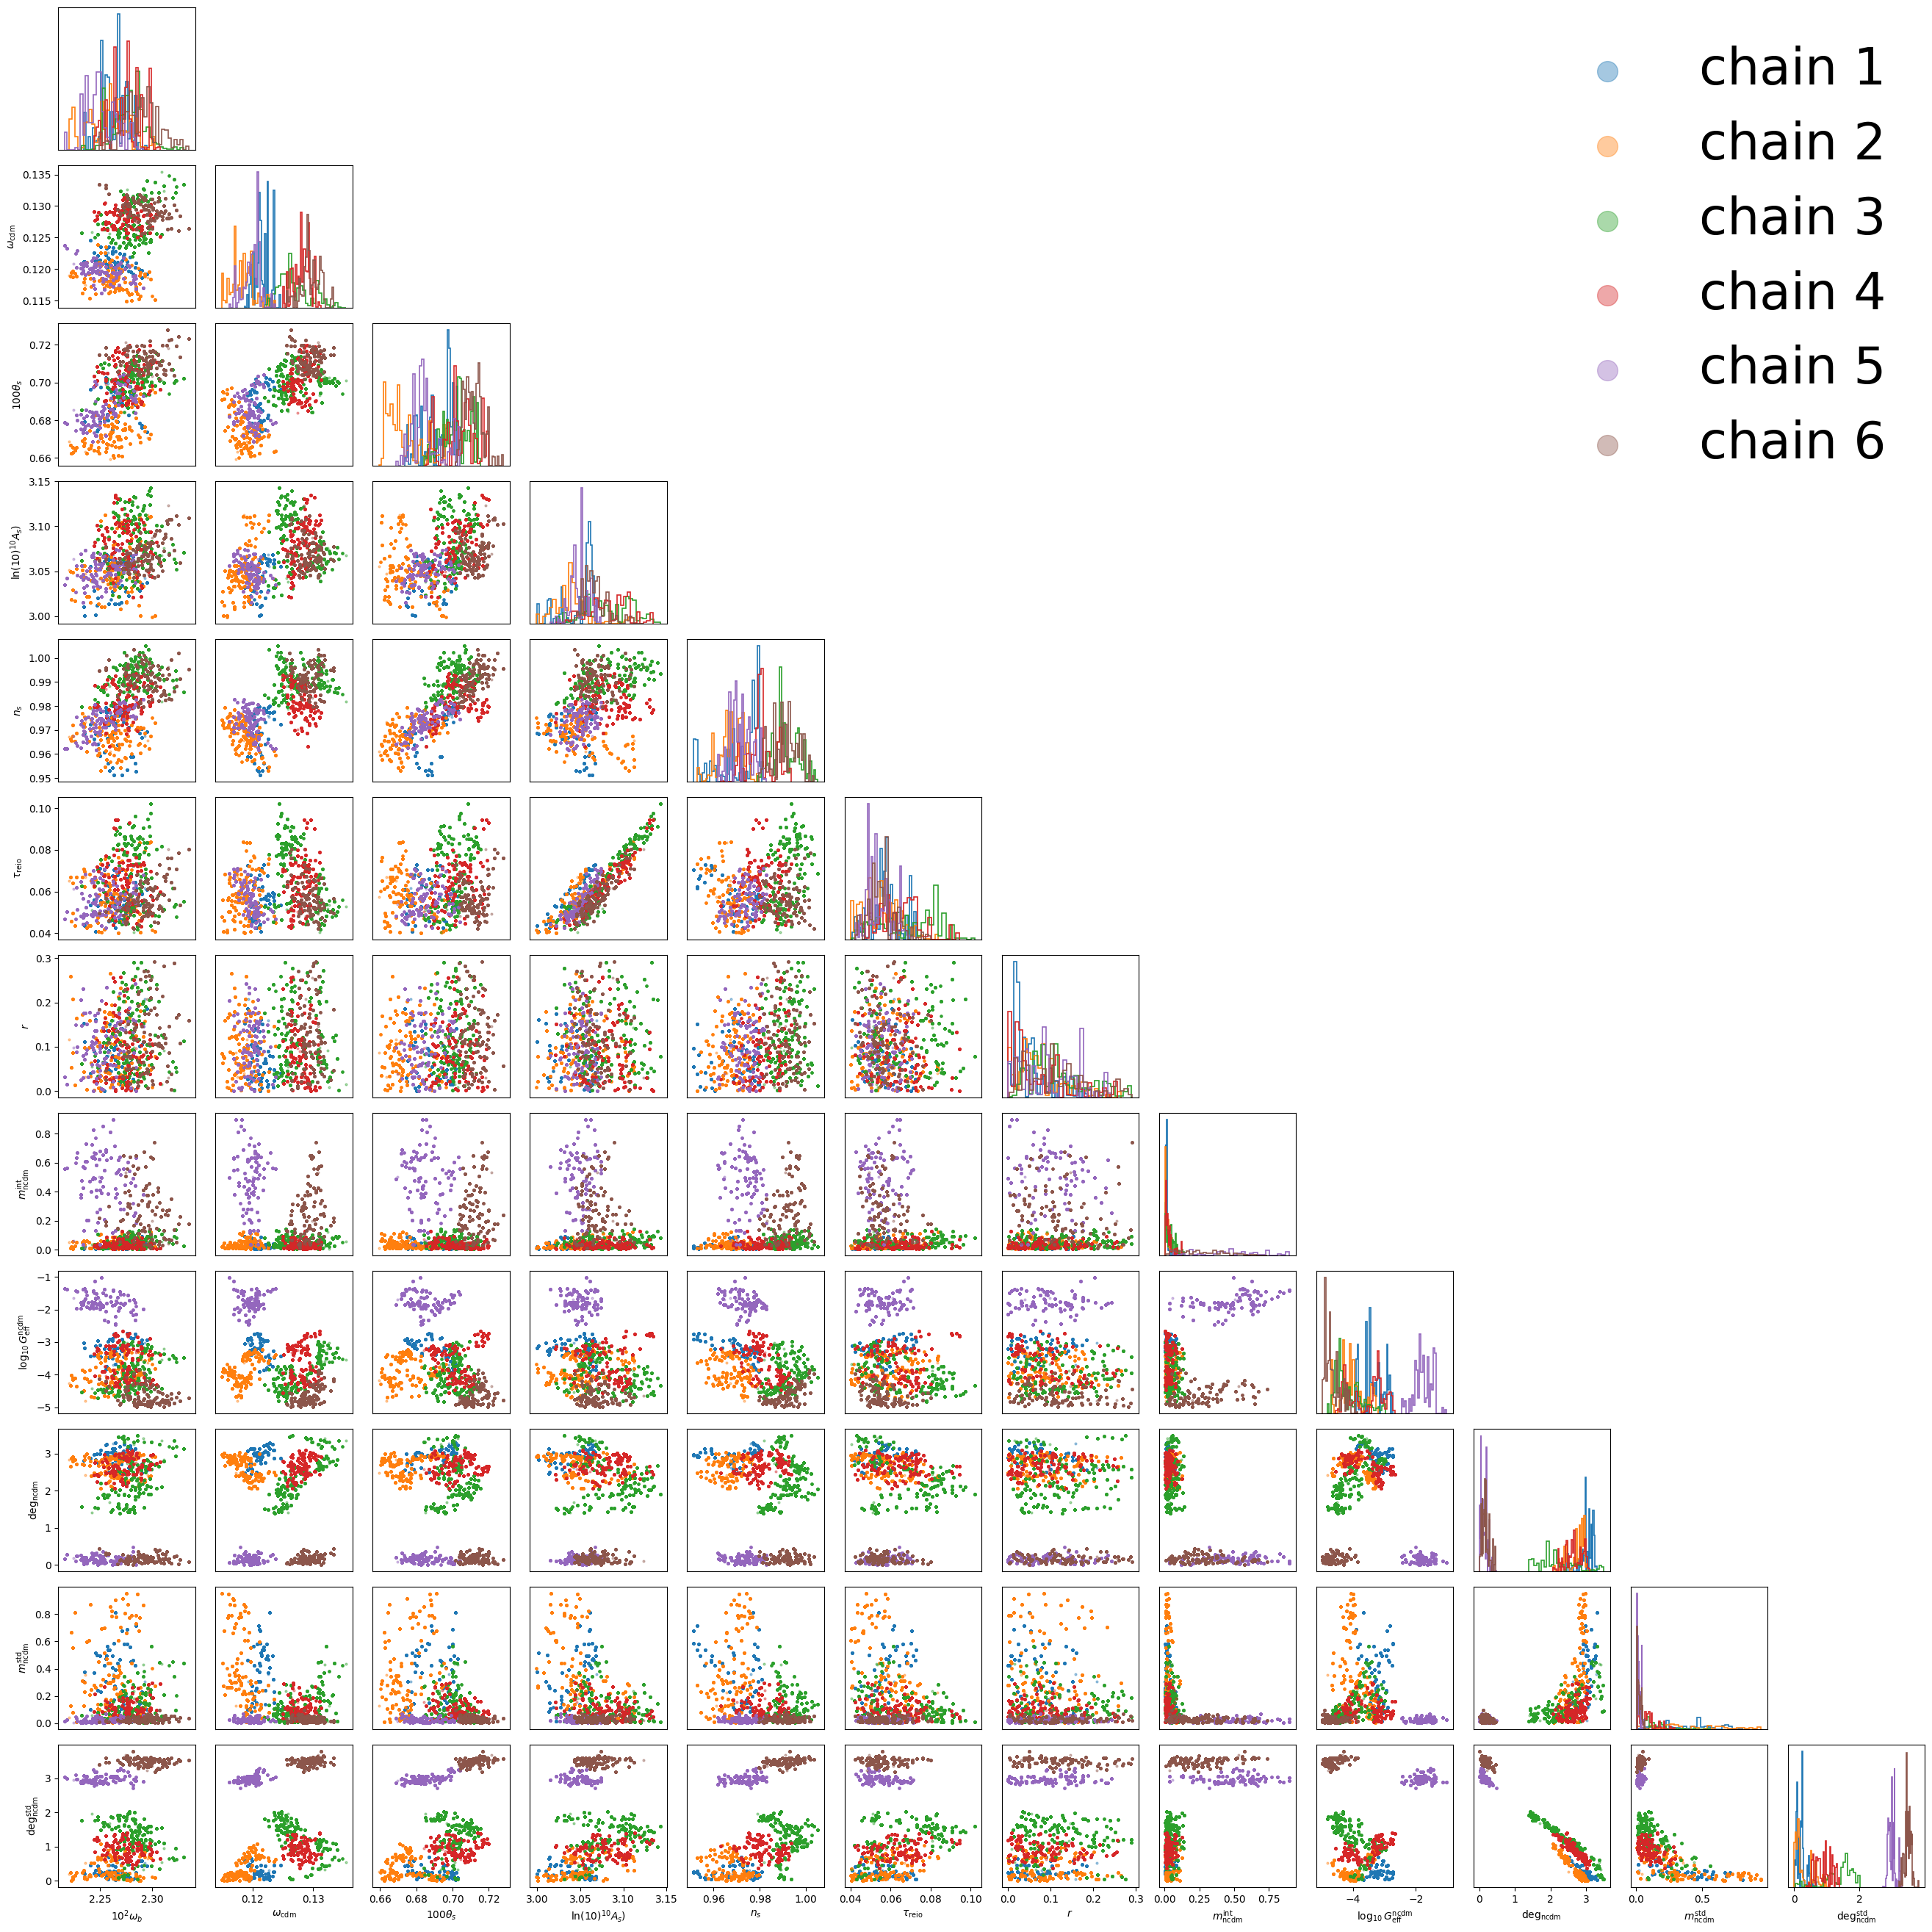

6 chains plotted.


In [13]:
#Checking the T_3 chain with only 200k steps 


# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
chain_dir = "/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3/"
chain_files = sorted(glob.glob(f"{chain_dir}/*.txt"))

n_chains = len(chain_files)
if n_chains == 0:
    raise RuntimeError("No chain files found")

# ------------------------------------------------------------------
# Parameters (ORDER MATTERS)
# ------------------------------------------------------------------
param_names = [
    "omega_b",
    "omega_cdm",
    "h",
    "ln10^{10}A_s",
    "n_s",
    "tau_reio",
    "r",
    "m_ncdm_interacting",
    "log10G_eff_ncdm_interacting",
    "deg_ncdm_interacting",
    "m_ncdm_standard",
    'deg_ncdm_standard'
]

param_labels = [
    r"$10^{2}\omega_b$",
    r"$\omega_{\rm cdm}$",
    r"$100\theta_s$",
    r"$\ln(10)^{10}A_s)$",
    r"$n_s$",
    r"$\tau_{\rm reio}$",
    r"$r$",
    r"$m_{\rm ncdm}^{\rm int}$",
    r"$\log_{10} G_{\rm eff}^{\rm ncdm}$",
    r"${\rm deg}_{\rm ncdm}$",
    r"$m_{\rm ncdm}^{\rm std}$",
    r"${\rm deg}_{\rm ncdm}^{\rm std}$"
]

n_params = len(param_names)

# ------------------------------------------------------------------
# Load chains separately
# ------------------------------------------------------------------
chains = []

for f in chain_files:
    data = np.loadtxt(f)
    params = data[-15000:, 2:16]  # drop step + -loglike
    chains.append(params)

for i, chain in enumerate(chains):
    print(f"Chain {i}: {chain.shape}")
# ------------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------------
colors = plt.cm.tab10.colors  # distinct chain colors
alpha = 0.4
s = 4  # marker size

fig, axes = plt.subplots(
    n_params, n_params,
    figsize=(2.2 * n_params, 2.2 * n_params),
    squeeze=False
)

# ------------------------------------------------------------------
# Triangle plotting
# ------------------------------------------------------------------
for i in range(n_params):
    for j in range(n_params):

        ax = axes[i, j]

        # Upper triangle: empty
        if j > i:
            ax.axis("off")
            continue

        # Diagonal: 1D histograms
        if i == j:
            for c, chain in enumerate(chains):
                ax.hist(
                    chain[:, i],
                    bins=30,
                    histtype="step",
                    color=colors[c % len(colors)],
                    linewidth=1.2,
                    density=True,
                )
        # Lower triangle: 2D scatter
        else:
            for c, chain in enumerate(chains):
                ax.scatter(
                    chain[:, j],
                    chain[:, i],
                    s=s,
                    alpha=alpha,
                    color=colors[c % len(colors)],
                    label=f"chain {c+1}" if (i == n_params - 1 and j == 0) else None,
                )

        # Labels
        if i == n_params - 1:
            ax.set_xlabel(param_labels[j], fontsize=10)
        else:
            ax.set_xticks([])

        if j == 0 and i != 0:
            ax.set_ylabel(param_labels[i], fontsize=10)
        else:
            ax.set_yticks([])

# ------------------------------------------------------------------
# Legend (only once)
# ------------------------------------------------------------------
handles, labels = axes[-1, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    fontsize=50,
    frameon=False,
    markerscale=10
)

plt.tight_layout()
plt.show()

print(len(chain_files), "chains plotted.")
